In [5]:
import numpy as np
import cvxopt as cv
import random as rd
import matplotlib.pyplot as plt

     pcost       dcost       gap    pres   dres
 0: -3.3290e+06 -2.0184e+02  7e+06  3e+03  9e-01
 1: -3.3462e+04 -2.0184e+02  7e+04  3e+01  9e-03
 2: -5.0671e+02 -2.0179e+02  7e+02  3e-01  9e-05
 3: -2.9225e+02 -1.9991e+02  2e+02  1e-01  3e-05
 4: -2.5948e+02 -2.0050e+02  2e+02  8e-02  2e-05
 5: -2.4007e+02 -2.0137e+02  2e+02  7e-02  2e-05
 6: -1.7920e+02 -2.0142e+02  2e+01  5e-16  8e-15
 7: -1.9816e+02 -1.9985e+02  2e+00  1e-15  3e-15
 8: -1.9938e+02 -1.9968e+02  3e-01  2e-16  3e-15
 9: -1.9964e+02 -1.9966e+02  3e-02  2e-15  3e-15
10: -1.9966e+02 -1.9966e+02  3e-04  2e-15  3e-15
11: -1.9966e+02 -1.9966e+02  3e-06  4e-16  3e-15
Optimal solution found.
[[19.98311743]]
[[-0.03417008  0.00810732]]


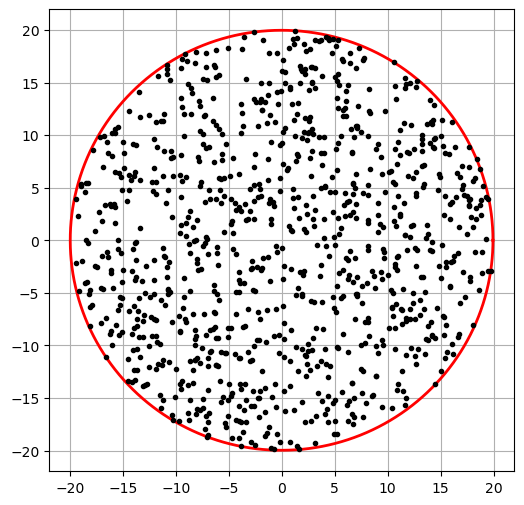

In [94]:
n = 1000

A0 = []

desired = 20

for i in range(n):
    x = 1000
    y = 1000
    while (x ** 2 + y ** 2 > desired ** 2):
        x = rd.uniform(-1000, 1000)
        y = rd.uniform(-1000, 1000)
    A0.append([x, y])

A0 = np.array(A0)

b0 = []

for i in range(n):
    sum = 0
    for j in range(len(A0[i])):
        sum += 0.5 * A0[i][j]**2
    b0.append(sum)


p = cv.matrix(-np.array(b0))

Q = cv.matrix(np.dot(A0, A0.T))

G = cv.matrix(-np.eye(n))

h = cv.matrix(np.zeros(n))

A = cv.matrix(np.array([1.0] * n), (1, n))

b = cv.matrix(1.0)


solution = cv.solvers.qp(Q, p, G, h, A, b)

u = solution['x']

u = u.T

center = np.dot(u, A0)


f = 0.5 * np.linalg.norm(np.dot(u, A0))**2 + u * p

radius = (-2 * f)**0.5

theta = np.linspace(0, 2 * np.pi, 1000)

x = radius * np.cos(theta)
y = radius * np.sin(theta)

print(radius)

print(center)

x += center[0][0]
y += center[0][1]


plt.figure(figsize=(6, 6))
plt.errorbar(A0.T[0], A0.T[1], fmt=".k")
plt.plot(x[0], y[0], "r", linewidth=2)
plt.grid()
plt.show()






     pcost       dcost       gap    pres   dres
 0:  1.8889e+00  7.7778e-01  1e+00  3e-16  2e+00
 1:  1.8769e+00  1.8320e+00  4e-02  1e-16  6e-02
 2:  1.8750e+00  1.8739e+00  1e-03  2e-16  5e-04
 3:  1.8750e+00  1.8750e+00  1e-05  1e-16  5e-06
 4:  1.8750e+00  1.8750e+00  1e-07  3e-16  5e-08
Optimal solution found.
[ 2.50e-01]
[ 7.50e-01]

[ 1.00e+00  1.00e+00]



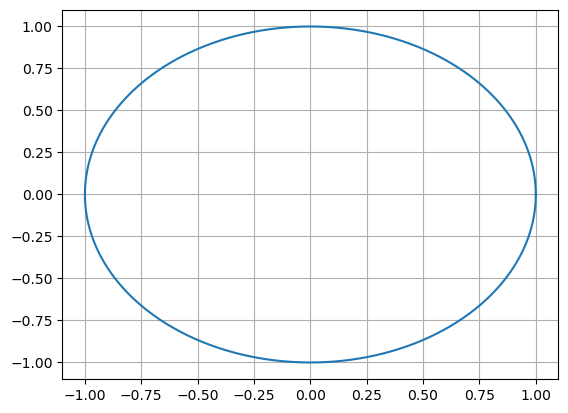

In [74]:
from cvxopt import matrix, solvers
Q = 2*matrix([ [2, .5], [.5, 1] ])
p = matrix([1.0, 1.0])
G = matrix([[-1.0,0.0],[0.0,-1.0]])
h = matrix([0.0,0.0])
A = matrix([1.0, 1.0], (1,2))
b = matrix(1.0)
sol=solvers.qp(Q, p, G, h, A, b)
print(sol['x'])

print(A)

theta = np.linspace(0, 2*np.pi, 1000)

x = np.cos(theta)
y = np.sin(theta)

plt.plot(x, y)
plt.grid()
plt.show()